## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import ndimage
import matplotlib.patches as patches
from tqdm import tqdm
# import cv2
import os
import random
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import gc 
import tensorflow as tf
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from dataclasses import dataclass
from matplotlib import patches
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import sys
import time 
import tensorflow as tf
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

from tqdm import tqdm
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.colors as mcolors
import re, glob
from skimage.transform import resize
from typing import Dict, Tuple, Optional, Sequence
import cv2
import matplotlib.patches as patches
import psutil
from pprint import pprint

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
# Check GPUs

print("GPUs available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

# Get memory info
mem = psutil.virtual_memory()
from pprint import pprint

# load the functions
path_functions = str(Path(__file__).parent)
sys.path.append(path_functions)

from LNP_LNLN_Functions import *

GPUs available: 2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## RGC Parameters 


In [2]:
pprint(RGC_PARAMS)
mosaic_params = get_biological_mosaic_parameters()


{'OFF_Midget': {'alpha': 1,
                'alpha_sub': 1,
                'amp1': 0.5,
                'amp2': 0.05,
                'beta': 1,
                'beta_sub': 10,
                'center_size': 3.3333333333333335,
                'center_strength': 1.0,
                'gamma': 0,
                'gamma_lnln': 2,
                'gamma_sub': 0,
                'peak1_ms': 30,
                'peak2_ms': 100,
                'surround_size': 6.666666666666667,
                'surround_strength': -0.5,
                'width1_ms': 25,
                'width2_ms': 50},
 'OFF_Parasol': {'alpha': 1,
                 'alpha_sub': 1,
                 'amp1': 0.5,
                 'amp2': 0.15,
                 'beta': 2,
                 'beta_sub': 10,
                 'center_size': 8.333333333333334,
                 'center_strength': 1.0,
                 'gamma': 0,
                 'gamma_lnln': 2,
                 'gamma_sub': 0,
                 'peak1_ms': 20,
      

## Natural Movie


Attempting to load: C:\LNP_Model\lnp_naturalmovies\Video_2.mp4
  Total frames: 898
  Original size: 1920x1080
Loading frames [0:76) → 76 frames
  Loaded frame 0
  Loaded frame 25
  Loaded frame 50
  Loaded frame 75
Loaded movie shape: (76, 35, 35)  (dtype=float32)
Attempting to load: C:\LNP_Model\lnp_naturalmovies\Video_2.mp4
  Total frames: 898
  Original size: 1920x1080
Loading frames [440:898) → 458 frames
  Loaded frame 440
  Loaded frame 465
  Loaded frame 490
  Loaded frame 515
  Loaded frame 540
  Loaded frame 565
  Loaded frame 590
  Loaded frame 615
  Loaded frame 640
  Loaded frame 665
  Loaded frame 690
  Loaded frame 715
  Loaded frame 740
  Loaded frame 765
  Loaded frame 790
  Loaded frame 815
  Loaded frame 840
  Loaded frame 865
  Loaded frame 890
Loaded movie shape: (458, 35, 35)  (dtype=float32)
Reloaded movie shape: (458, 35, 35)


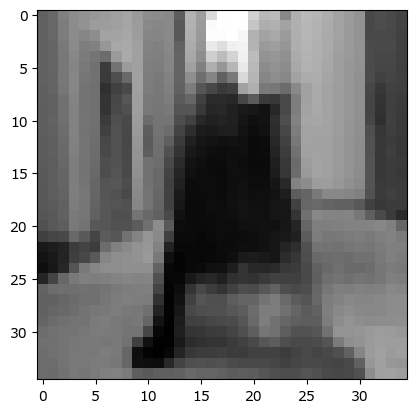

In [4]:

# path to the movie
video_path = 'C:\LNP_Model\lnp_naturalmovies\Video_2.mp4'


# load the movie
if os.path.exists(video_path):
    # load the movie
    movie = load_natural_movie_debug(video_path, frames=76, height=x, width=y)
    

# define the size of each frame (height and width) and number of frames 

height=35
width=35

movie = load_natural_movie_debug(video_path, start_frame=440, end_frame=1000, height=height, width=width)
print(f"Reloaded movie shape: {movie.shape}")

movie_NM=movie
stimulus_frame_NM=movie_NM[5,:,:]

# frame to display with mosaic 
stimulus_frame = movie_NM[1, :, :]  # Get any frame you want


plt.imshow(stimulus_frame[:,:], cmap='gray')

## Windowed stimulus (8.3ms/frame)

In [5]:
neuron_memory=250
temp_filter=create_temporal_filter(peak1_ms=40, peak2_ms=120, width1_ms=30, width2_ms=60,
                          frame_rate=120, memory_ms=neuron_memory, smooth_onset=True, cell_type='ON')

# get the windowed stimulus (after applying rolling window)
stim_windowed = compute_stim_windowed(movie,temp_filter)
print(f"windowed stimulus shape : {stim_windowed.shape}")

#visaul field (width and height of the movie)
x=stim_windowed.shape[2]
y= stim_windowed.shape[3]


# temporal filter
dt=8.3 #ms (bin size in ms)
cell_memory_ms=stim_windowed.shape[1]*dt
cell_memory_frame=stim_windowed.shape[1]

windowed stimulus shape : (429, 30, 35, 35)


## Plot Spatial, temporal and nonlinearity functions 

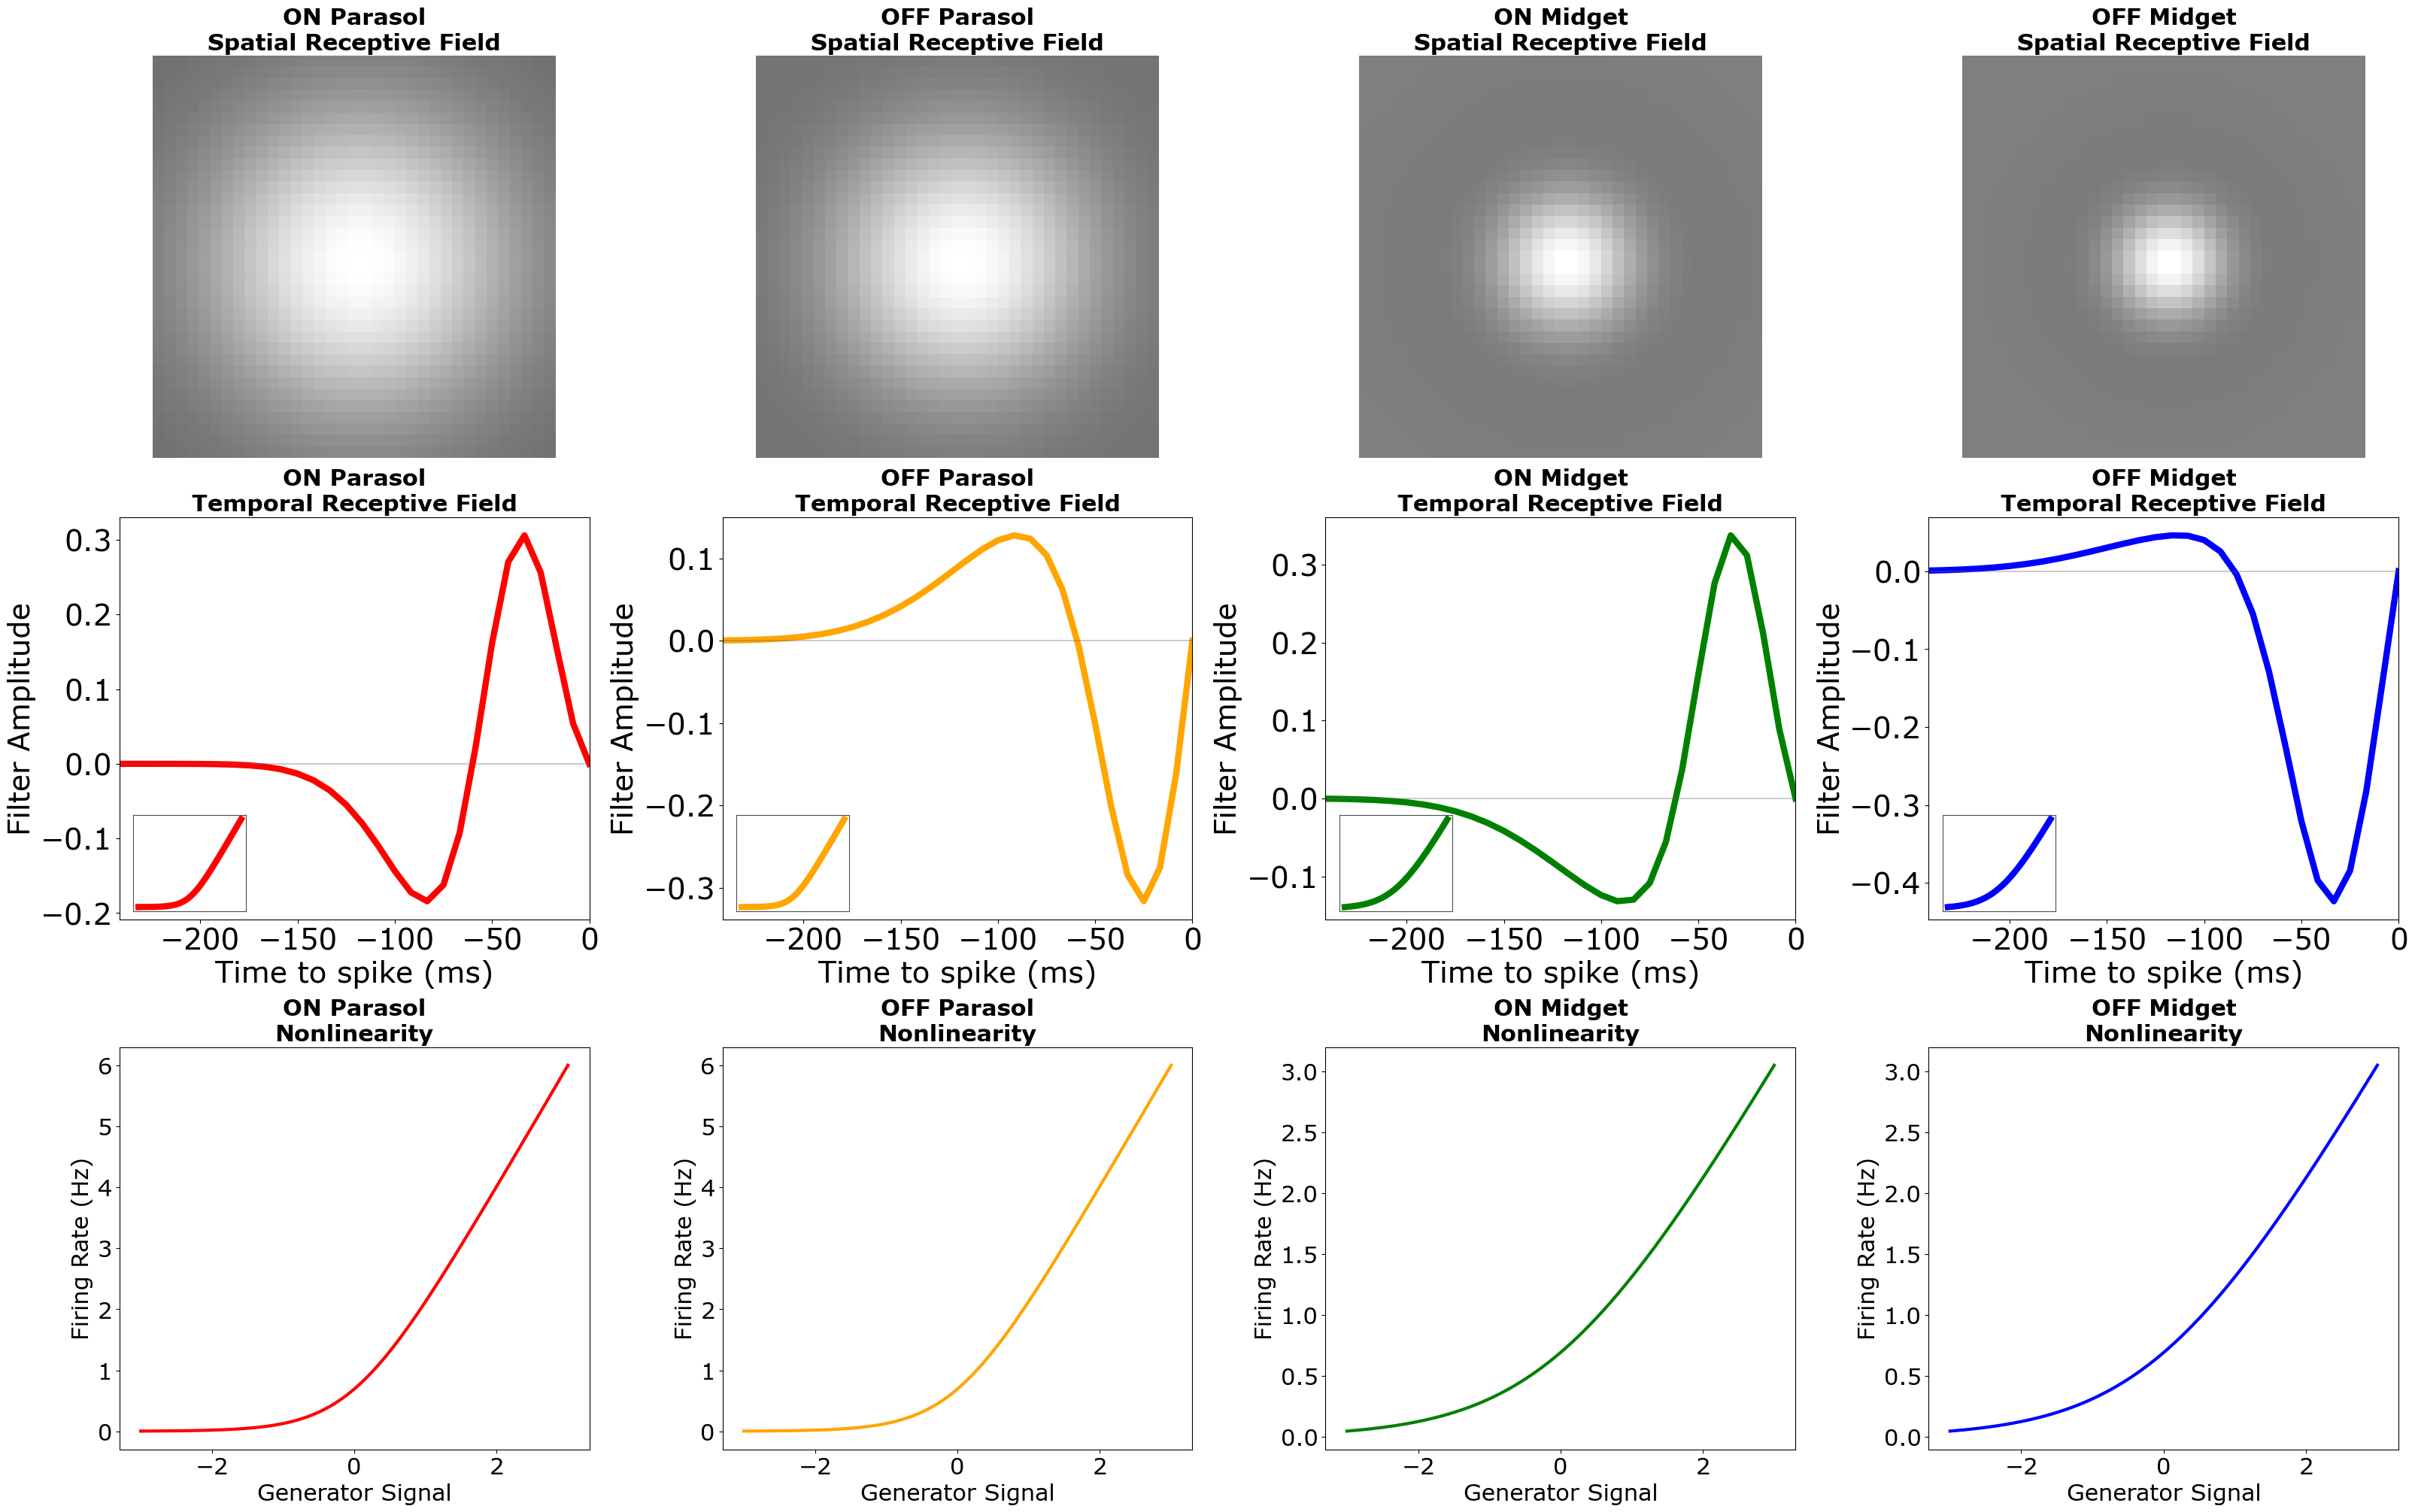

In [6]:
fig, _ = plot_rgc_components(
    RGC_PARAMS,
    create_spatial_filter,
    create_temporal_filter,
    apply_nonlinearity,
    inset_size=("24%", "24%"),   # larger inset
    inset_loc=(0.03, 0.02),      # move upward
)


## Mosaic of each RGC Type 

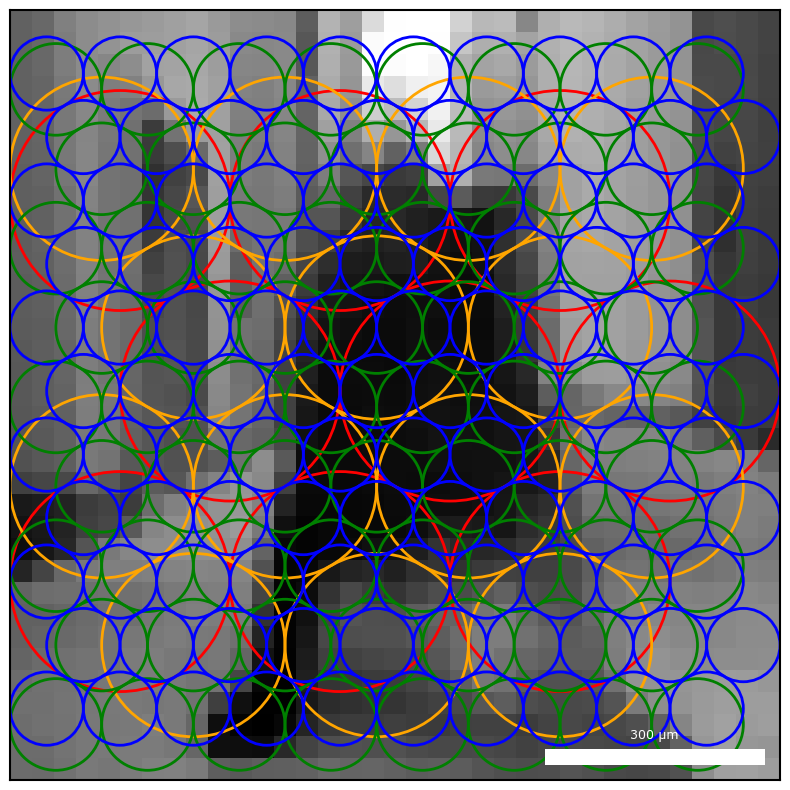

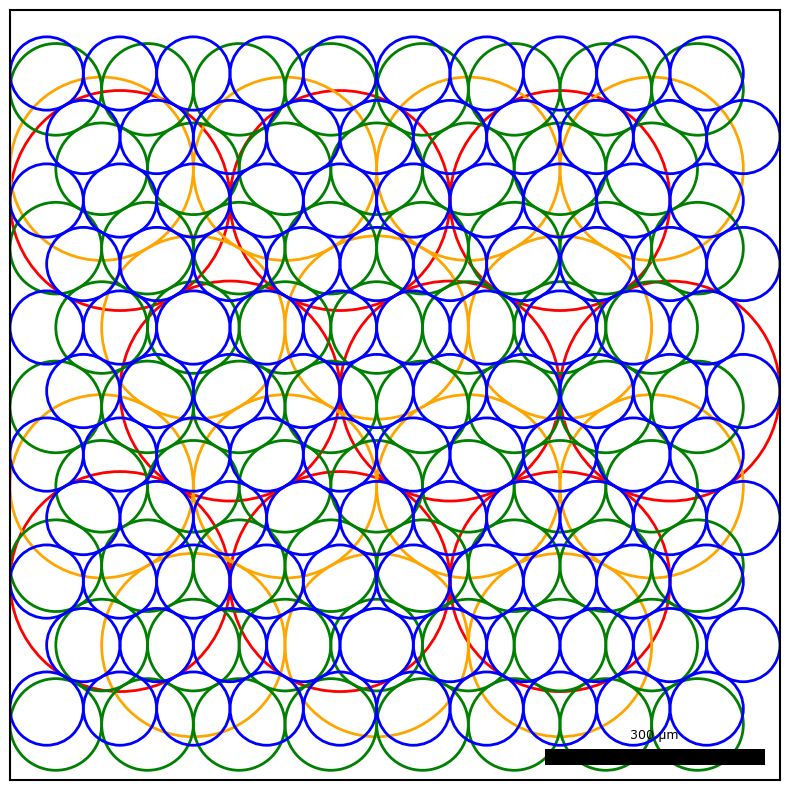

In [7]:
# 2. Tile the space 
stimulus = stimulus_frame
H, W = stimulus.shape[:2]
x= 35
y= 35


overlay_config = [
   {'cell_type': 'ON_Parasol', 'n_cells':None, 'coverage_factor':1},
  {'cell_type': 'OFF_Parasol', 'n_cells':None, 'coverage_factor':1, 'offset': (0, 0)},
  {'cell_type': 'ON_Midget', 'n_cells': None, 'coverage_factor': 1},
  {'cell_type': 'OFF_Midget', 'n_cells':None, 'coverage_factor':1, 'offset': (0, 0)}
]

overlaid_mosaic = create_flexible_overlaid_mosaic((H, W), overlay_config,
                                                  keep_boundary_cells=False)


# visualize the mosaic 
fig, ax = plot_simple_mosaic(
    overlaid_mosaic, 
    stimulus_frame=stimulus_frame,
    show_stimulus=True,
    title=None,
    scale_bar_length_um=300, 
    px_per_um=(1.0/30.0),
    scale_bar_color='white'
)

# White background (same size as stimulus)
fig, ax = plot_simple_mosaic(
    overlaid_mosaic, 
    stimulus_frame=stimulus_frame,
    show_stimulus=False,
    title=None,
    scale_bar_length_um=300, 
    px_per_um=(1.0/30.0)
)




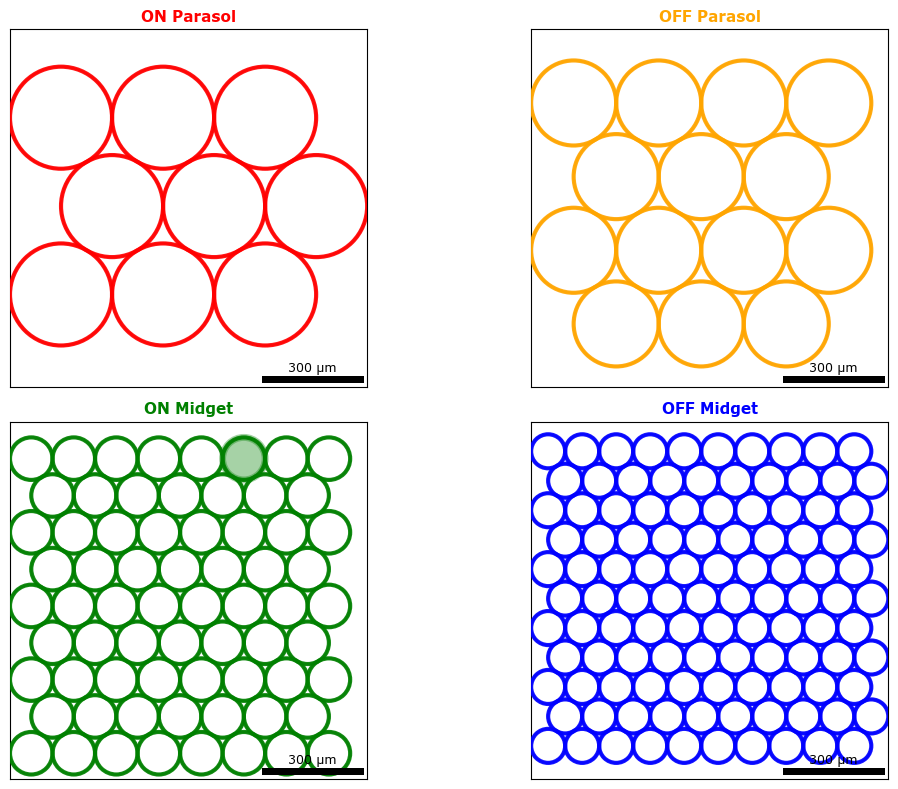

In [8]:

# Get separate plot for each RGC type mosaic 

px_per_um = 1.0 / 30.0      # pixels per µm when 1 pixel = 30 µm
FRAME_HEIGHT = 35
FRAME_WIDTH =35
visual_field_size = (FRAME_HEIGHT, FRAME_WIDTH)
cell_index=5

fig, axes = plot_mosaic_grid(
    overlaid_mosaic, visual_field_size=(H, W),
    # scale bar
    scale_bar_length_um=300, px_per_um=(1.0/30.0), scale_bar_units='um',
    # ring EVERY RF
    highlight_all=True,
    highlight_all_fill=False,          # ring only
    highlight_all_edgecolor='auto',    # match RF color
    highlight_all_lw=3.0,
    highlight_all_alpha=0.9,
    # EMPHASIZE this one cell
    highlight_type='ON_Midget',
    highlight_index=cell_index,        # your chosen index
    highlight_fill=True,               # filled disk
    highlight_facecolor='auto',        # fill matches RF color
    highlight_edgecolor='auto',
    highlight_lw=5,
    highlight_alpha=0.35
)


# overlaid RFs on natural image 
all_types_mosaic = create_flexible_overlaid_mosaic((x,y), overlay_config)

## Compute responses to the original movie (LNP)

Processing cells: 100%|██████████| 201/201 [00:03<00:00, 50.65it/s]


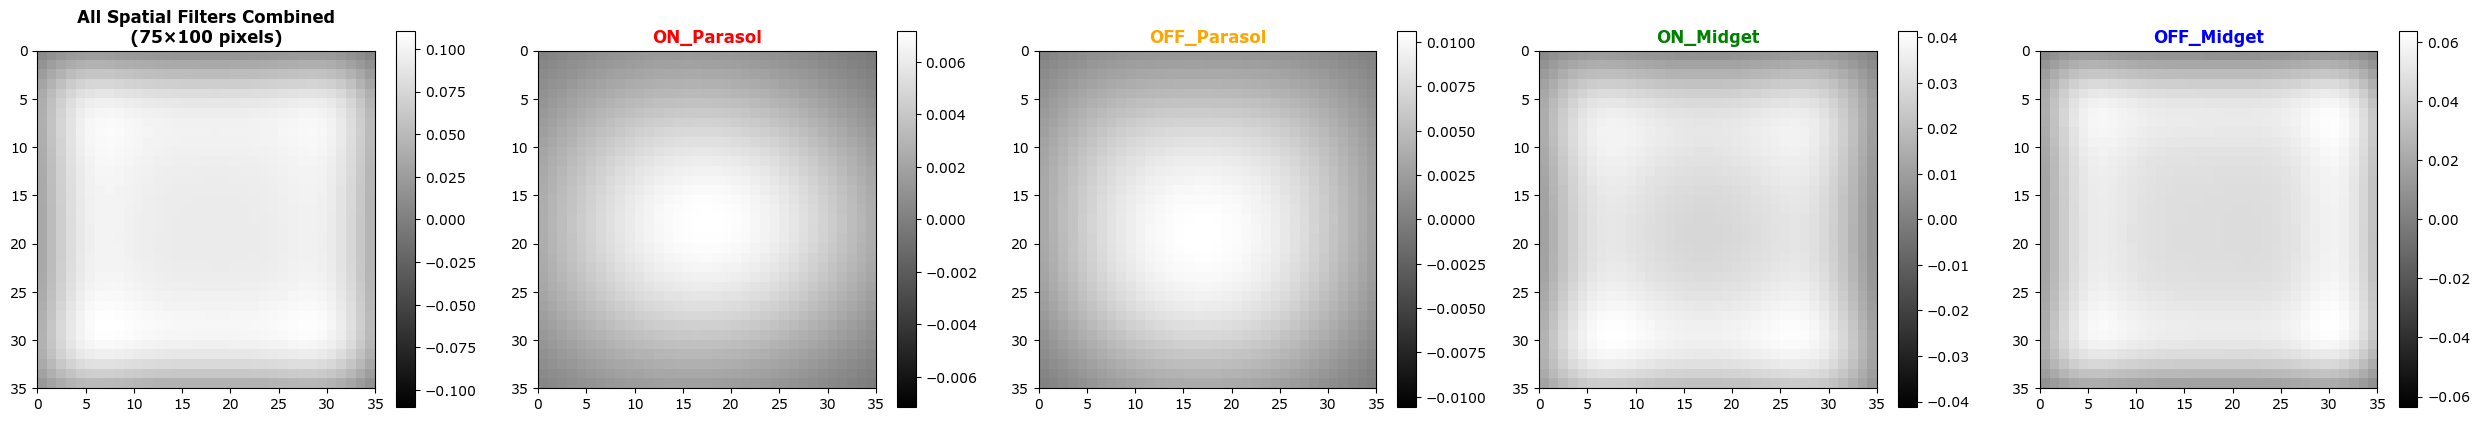

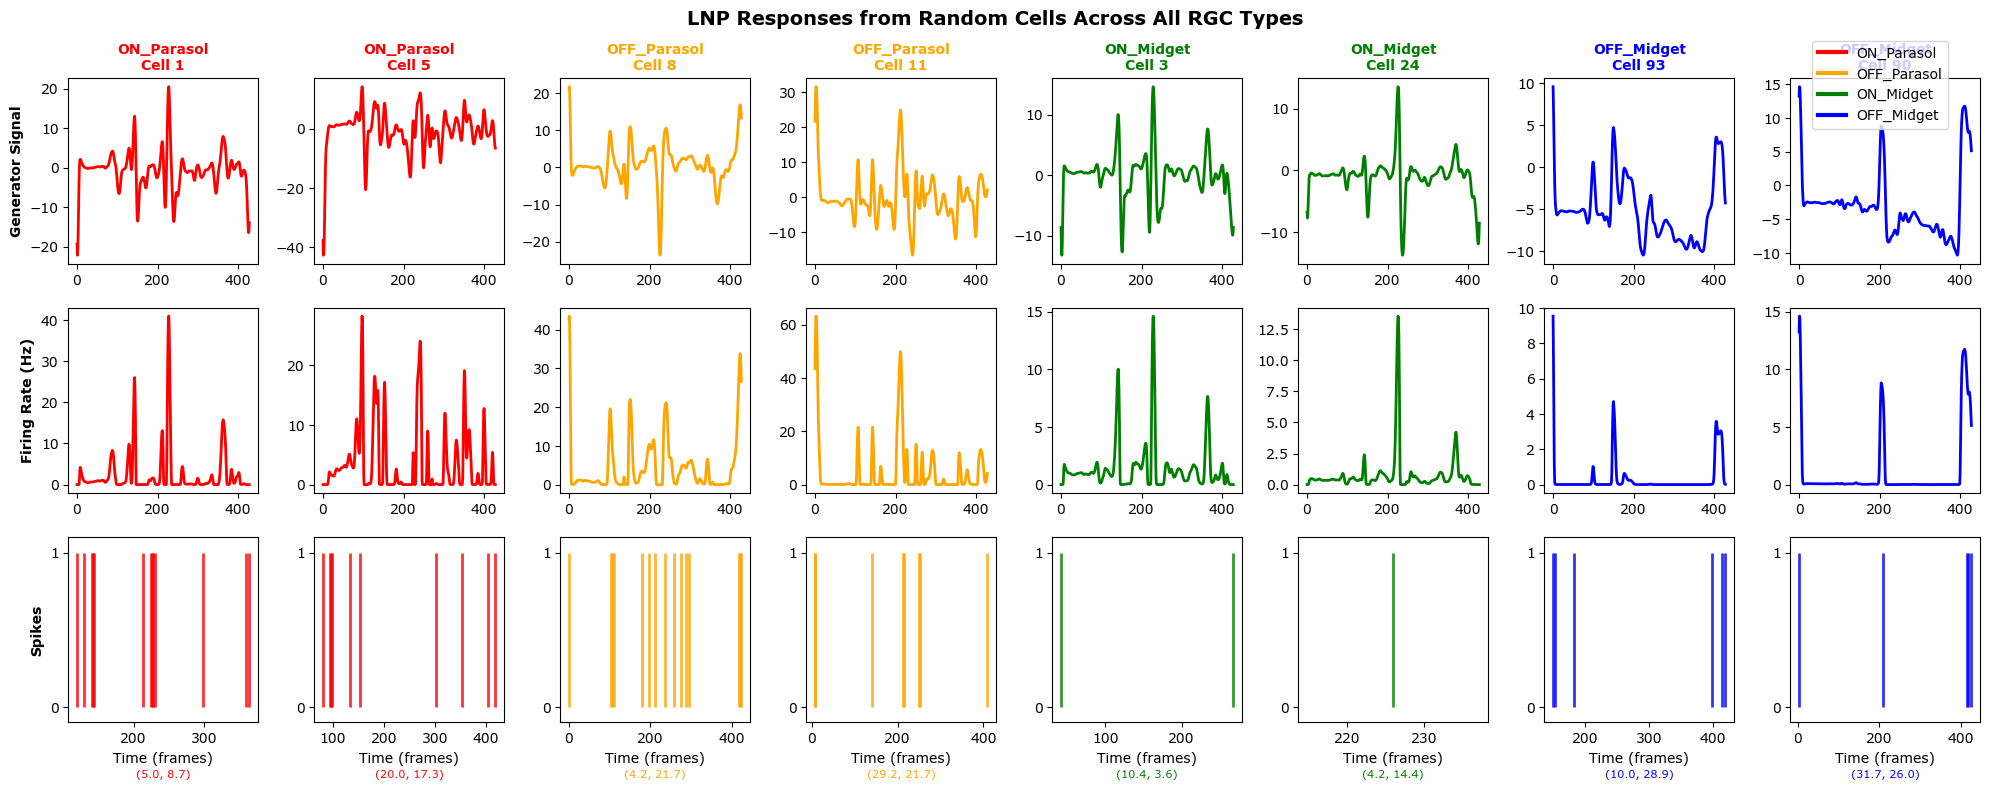

ON_Parasol   (red   ):   9 cells
OFF_Parasol  (orange):  14 cells
ON_Midget    (green ):  68 cells
OFF_Midget   (blue  ): 110 cells


In [9]:
# LNP model: Responses of all RGCs 
responses = compute_lnp_for_mosaic_final(stim_windowed, overlaid_mosaic, dt=8.3)

# Plot firing rate, generator signal and spikes 
fig1, fig2 = plot_final_results(overlaid_mosaic, responses, movie=stim_windowed)

## Compute responses to the original movie (LN-LN Cascade)

Computing LN-LN responses: 100%|██████████| 201/201 [00:12<00:00, 15.98it/s]


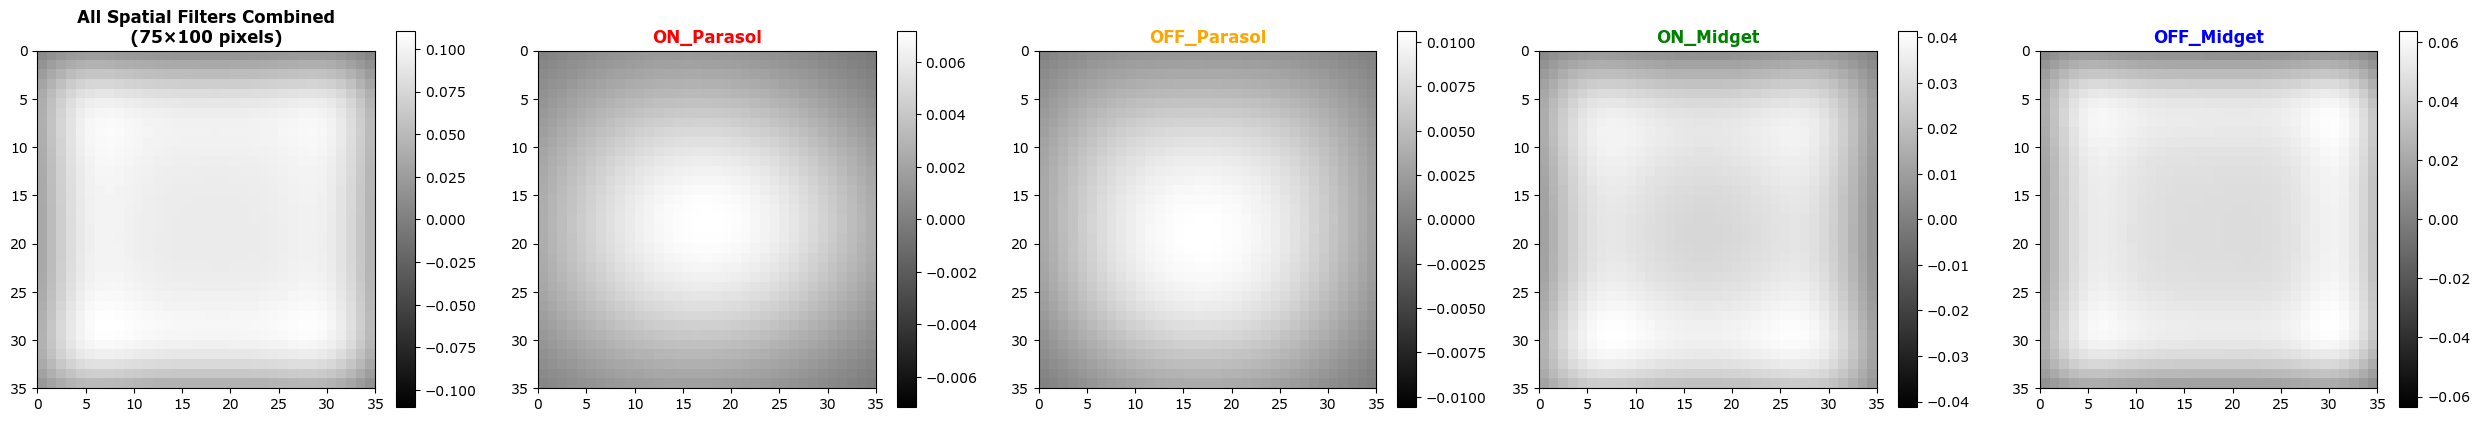

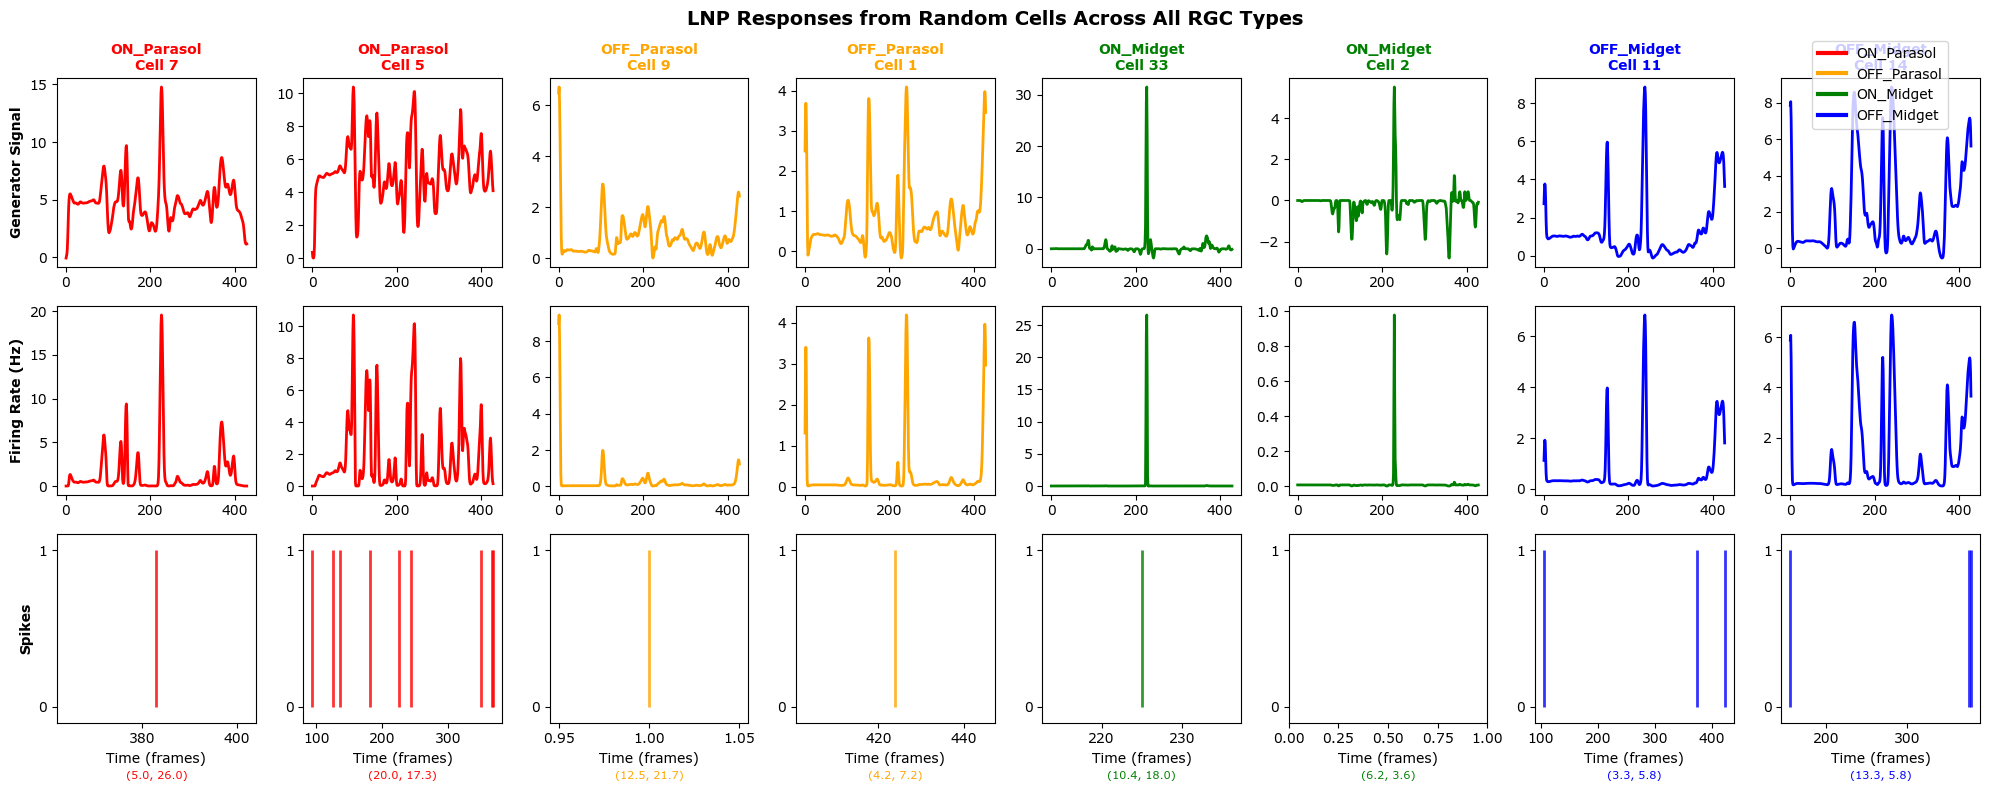

ON_Parasol   (red   ):   9 cells
OFF_Parasol  (orange):  14 cells
ON_Midget    (green ):  68 cells
OFF_Midget   (blue  ): 110 cells
ON_Parasol: mean g = 5.116
OFF_Parasol: mean g = 0.853
ON_Midget: mean g = 0.447
OFF_Midget: mean g = 1.909


In [14]:
# LN-LN model : Responses of all RGCs 
responses = compute_lnln_for_mosaic(stim_windowed, overlaid_mosaic)
# Plot firing rate, generator signal and spikes 
fig1, fig2 = plot_final_results(overlaid_mosaic, responses, movie=stim_windowed)


for rgc_type, cells in responses.items():
    g_mean = np.mean([c['generator_signal'].mean() for c in cells])
    print(f"{rgc_type}: mean g = {g_mean:.3f}")


## Raster plot 

Computing trial 1/100...


Processing cells: 100%|██████████| 201/201 [00:04<00:00, 47.43it/s]


Computing trial 2/100...


Processing cells: 100%|██████████| 201/201 [00:04<00:00, 47.78it/s]


Computing trial 3/100...


...

Processing cells: 100%|██████████| 201/201 [00:04<00:00, 44.77it/s]


Computing trial 99/100...


Processing cells: 100%|██████████| 201/201 [00:04<00:00, 45.52it/s]


Computing trial 100/100...


Processing cells: 100%|██████████| 201/201 [00:04<00:00, 46.26it/s]
C:\LNP_Model\Final_Draft_Code\GitHub_clean_codes\LNP_LNLN_Functions.py:2485: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


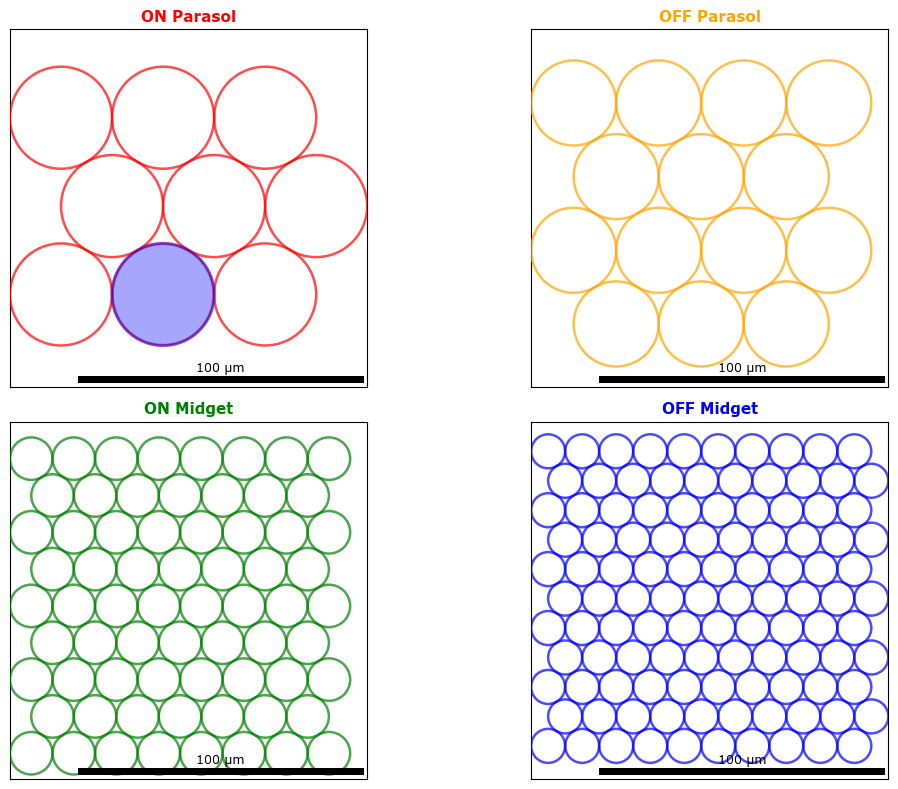

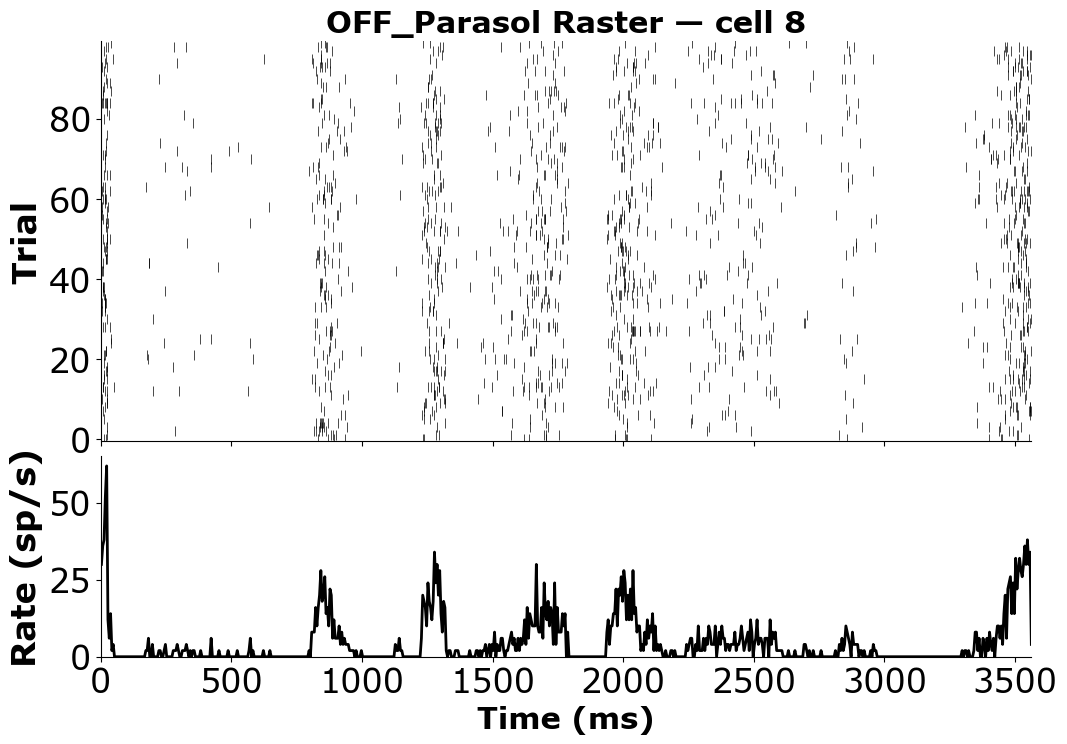

In [15]:
responses_trials = compute_lnp_with_multiple_trials(stim_windowed, overlaid_mosaic, n_trials=100)

# plot the mosaic 
cell_type   = 'ON_Parasol'
cell_index=7

fig, axes = plot_mosaic_grid(
    overlaid_mosaic,
    visual_field_size=(35,35),
    show_types=['ON_Parasol','OFF_Parasol','ON_Midget','OFF_Midget'],
    # scalebar
    scale_bar_length_um=100,
    px_per_um=0.5,
    # highlight the same cell
    highlight_type=cell_type,
    highlight_index=cell_index,
    highlight_fill=True,                    
    highlight_facecolor='blue',
    highlight_edgecolor='blue',
    highlight_alpha=0.35,
    highlight_lw=2.5
)

# plot raster plot 
fig = create_raster_and_psth_unified(
    responses_all_trials=responses_trials,
    rgc_type='OFF_Parasol',
    cell_index=cell_index,       # <— your chosen cell
    dt=8.3, axis_units='ms', bin_width=5,
    expand_counts_for_raster=False
)
